<a href="https://colab.research.google.com/github/suhani242/T170800236_TNS_AIML/blob/main/AIML_day13_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username": "shubhamdhangar866852", "key": "KGAT_2a650befd8f489325ab4f937c09e06c6"}'}

In [ ]:
import os
import shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [ ]:
!kaggle datasets download -d joebeachcapital/customer-segmentation

Dataset URL: https://www.kaggle.com/datasets/joebeachcapital/customer-segmentation
License(s): DbCL-1.0
100% 1.55k/1.55k [00:00<00:00, 4.10MB/s]



In [ ]:
import zipfile

zip_path = '/content/customer-segmentation.zip'

extract_path = '/content/customer_segmentation'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:


import os

os.listdir('/content/customer_segmentation')

['Mall_Customers.csv']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/customer_segmentation/Mall_Customers.csv')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:

df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numerical_columns

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns

Index(['Gender'], dtype='object')

In [ ]:
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Gender:
['Male' 'Female']


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

print("Duplicate rows removed successfully!")

Duplicate rows removed successfully!


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

print("Numerical missing values handled successfully!")

Numerical missing values handled successfully!


In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Categorical missing values handled successfully!")

Categorical missing values handled successfully!


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


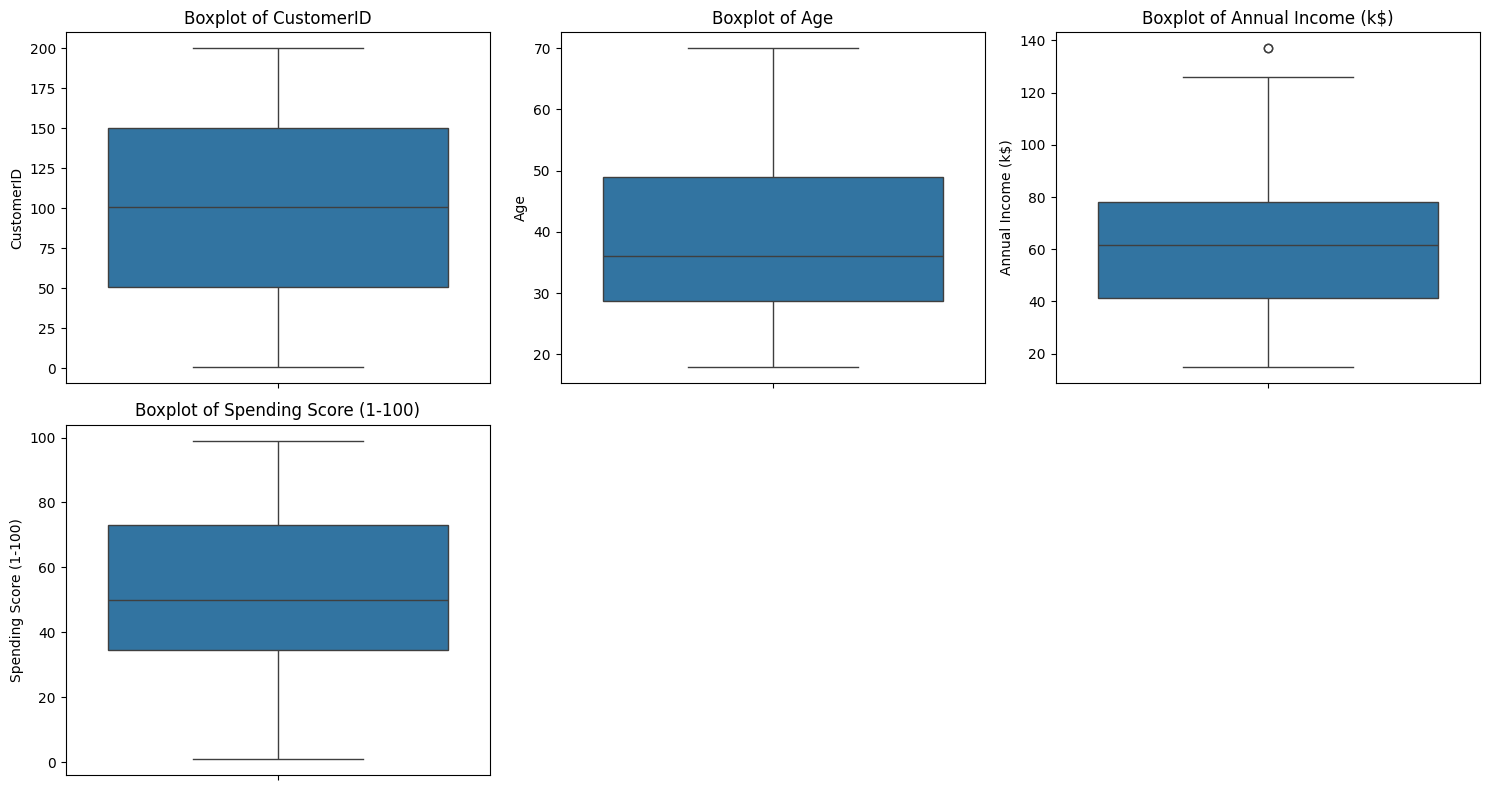

In [ ]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"{col} : {len(outliers)} outliers")

CustomerID : 0 outliers
Age : 0 outliers
Annual Income (k$) : 2 outliers
Spending Score (1-100) : 0 outliers


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Categorical features encoded successfully!")

Categorical features encoded successfully!


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


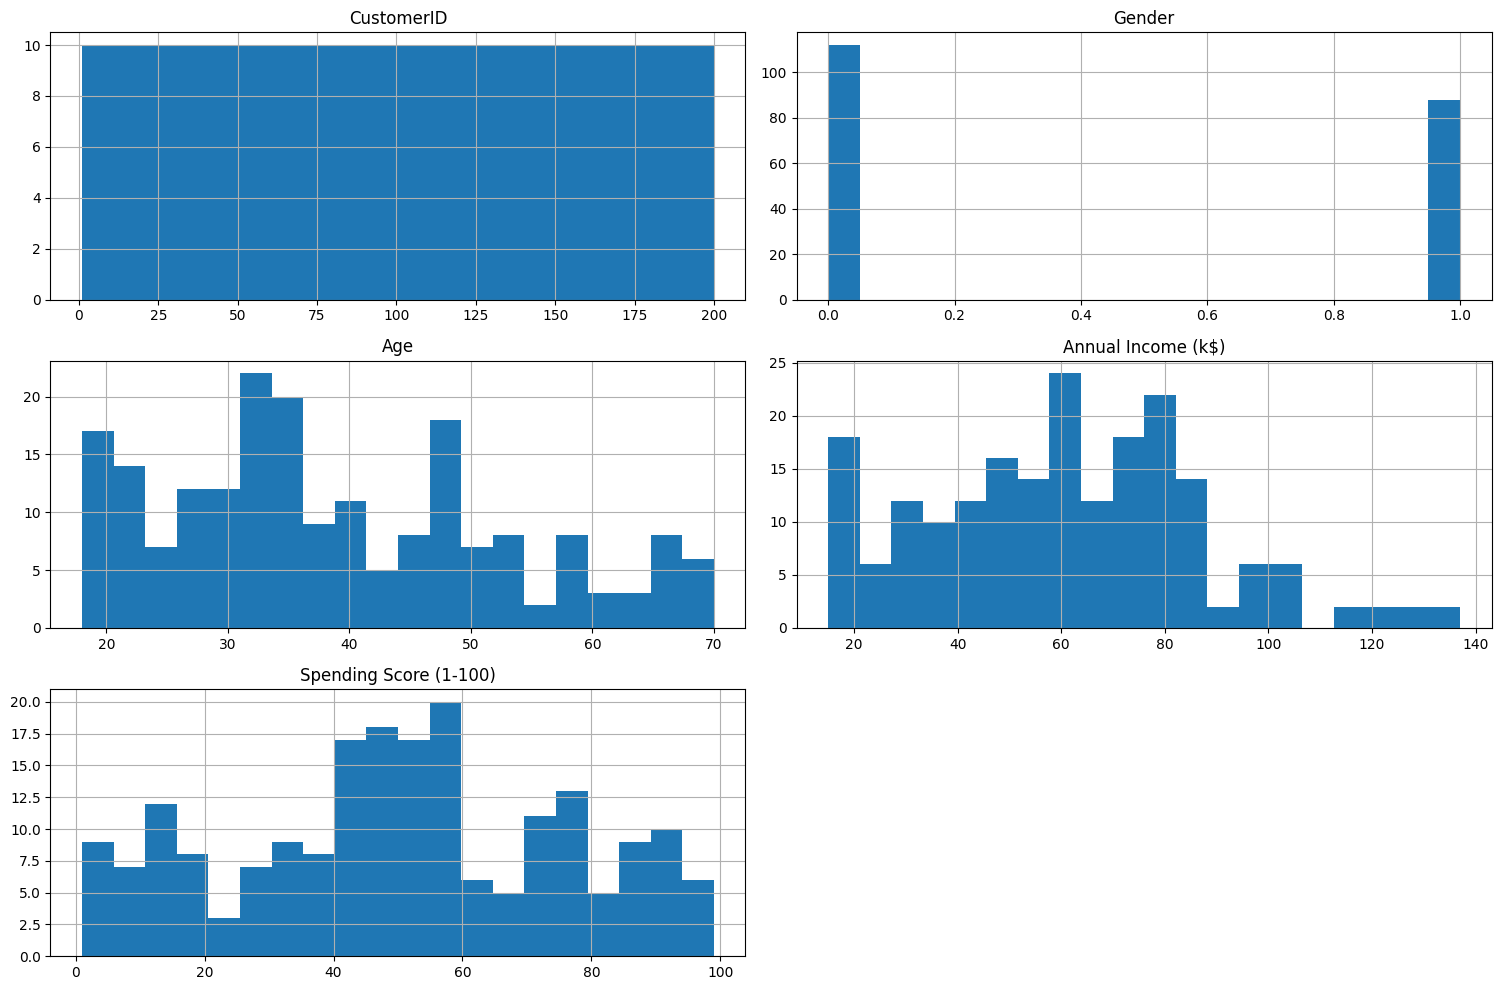

In [ ]:
df.hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

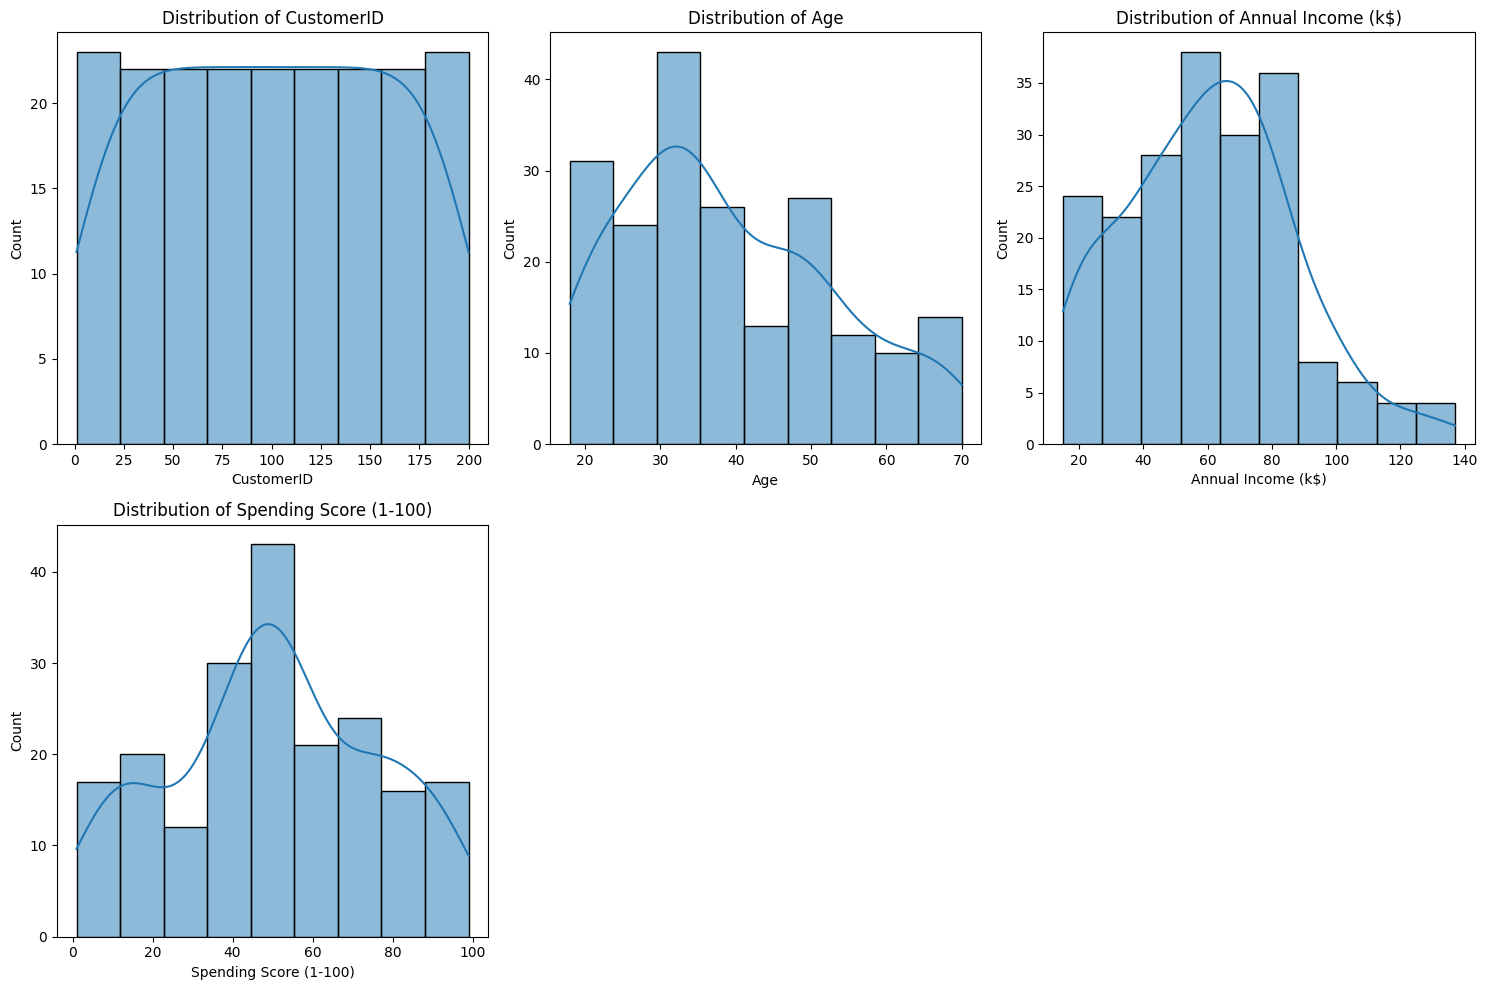

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

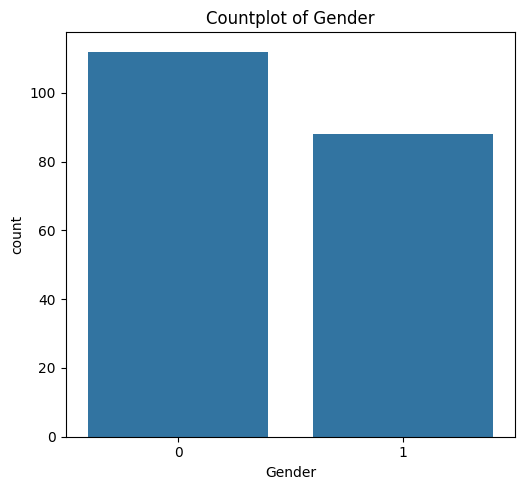

In [ ]:
plt.figure(figsize=(10,5))

for i, col in enumerate(categorical_columns):

    plt.subplot(1,2,i+1)
    sns.countplot(x=df[col])
    plt.title(f'Countplot of {col}')

plt.tight_layout()
plt.show()

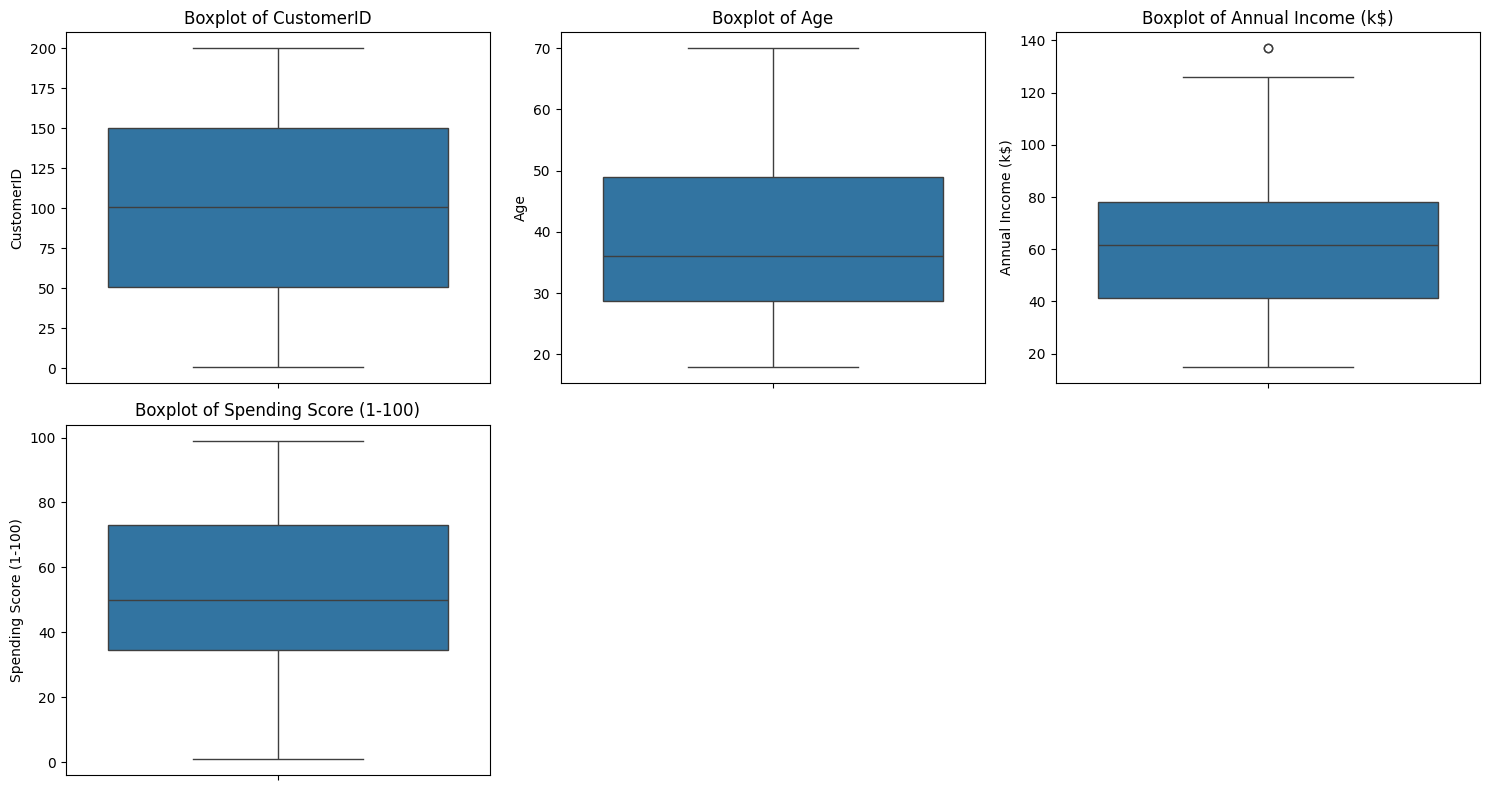

In [ ]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

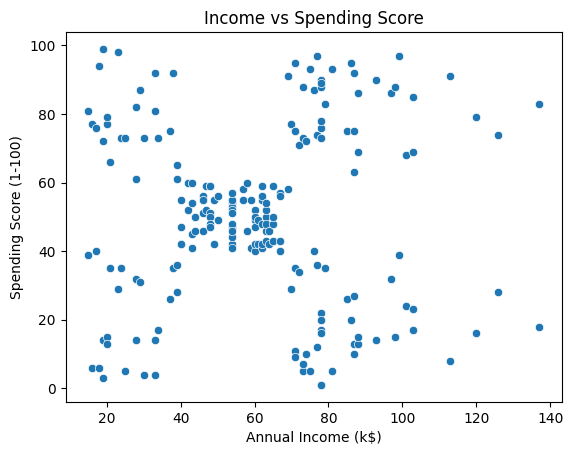

In [ ]:
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)']
)

plt.title('Income vs Spending Score')
plt.show()

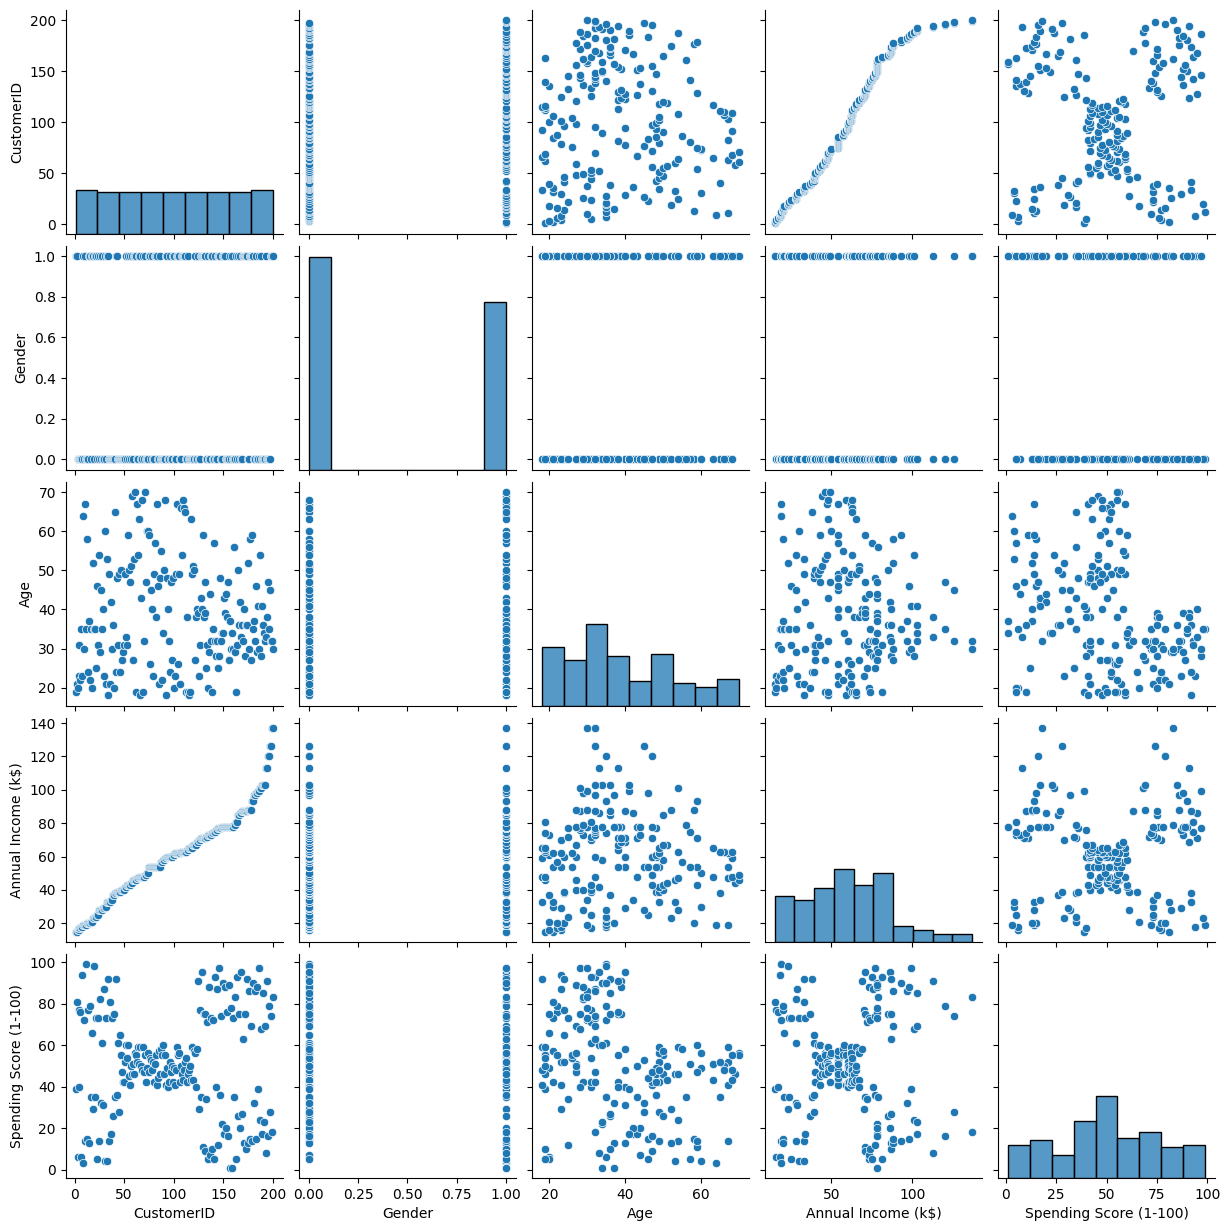

In [ ]:


sns.pairplot(df)

plt.show()

In [ ]:


correlation_matrix = df.corr()

correlation_matrix

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,0.057400,-0.026763,0.977548,0.013835
Gender,0.057400,1.000000,0.060867,0.056410,-0.058109
Age,-0.026763,0.060867,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,0.056410,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.058109,-0.327227,0.009903,1.000000


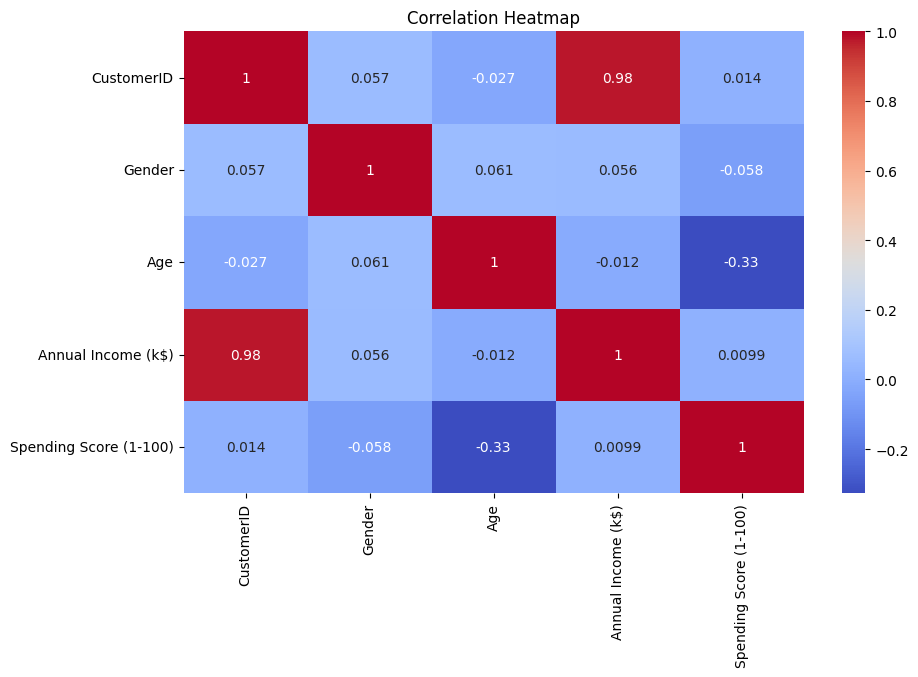

In [ ]:


plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

print("Irrelevant columns removed successfully!")

Irrelevant columns removed successfully!


In [ ]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 40, 60, 100],
    labels=['Young', 'Adult', 'Middle_Age', 'Senior']
)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_Group
0,1,19,15,39,Young
1,1,21,15,81,Young
2,0,20,16,6,Young
3,0,23,16,77,Young
4,0,31,17,40,Adult


In [ ]:
df['Income_Category'] = pd.cut(
    df['Annual Income (k$)'],
    bins=[0, 40, 70, 150],
    labels=['Low', 'Medium', 'High']
)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_Group,Income_Category
0,1,19,15,39,Young,Low
1,1,21,15,81,Young,Low
2,0,20,16,6,Young,Low
3,0,23,16,77,Young,Low
4,0,31,17,40,Adult,Low


In [ ]:
df['Spending_Category'] = pd.cut(
    df['Spending Score (1-100)'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High']
)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_Group,Income_Category,Spending_Category
0,1,19,15,39,Young,Low,Low
1,1,21,15,81,Young,Low,High
2,0,20,16,6,Young,Low,Low
3,0,23,16,77,Young,Low,High
4,0,31,17,40,Adult,Low,Low


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

new_categorical_columns = [
    'Age_Group',
    'Income_Category',
    'Spending_Category'
]

for col in new_categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("New categorical features encoded successfully!")

New categorical features encoded successfully!


In [ ]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_Group,Income_Category,Spending_Category
0,1,19,15,39,3,1,1
1,1,21,15,81,3,1,0
2,0,20,16,6,3,1,1
3,0,23,16,77,3,1,0
4,0,31,17,40,0,1,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [ ]:
scaled_data.shape

(200, 7)

In [ ]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_Group,Income_Category,Spending_Category
0,1.128152,-1.424569,-1.738999,-0.434801,1.739600,-0.011548,-0.177948
1,1.128152,-1.281035,-1.738999,1.195704,1.739600,-0.011548,-1.405172
2,-0.886405,-1.352802,-1.700830,-1.715913,1.739600,-0.011548,-0.177948
3,-0.886405,-1.137502,-1.700830,1.040418,1.739600,-0.011548,-1.405172
4,-0.886405,-0.563369,-1.662660,-0.395980,-0.929863,-0.011548,-0.177948


In [ ]:
scaled_df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_Group,Income_Category,Spending_Category
count,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,3.108624e-17,-1.021405e-16,-2.131628e-16,-1.465494e-16,3.552714e-17,-3.552714e-17,3.552714e-17
std,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,-8.864053e-01,-1.496335e+00,-1.738999e+00,-1.910021e+00,-9.298629e-01,-1.166325e+00,-1.405172e+00
25%,-8.864053e-01,-7.248436e-01,-7.275093e-01,-5.997931e-01,-9.298629e-01,-1.166325e+00,-1.405172e+00
50%,-8.864053e-01,-2.045351e-01,3.587926e-02,-7.764312e-03,-4.004194e-02,-1.154778e-02,-1.779476e-01
75%,1.128152e+00,7.284319e-01,6.656748e-01,8.851316e-01,8.497790e-01,1.143230e+00,1.049277e+00
max,1.128152e+00,2.235532e+00,2.917671e+00,1.894492e+00,1.739600e+00,1.143230e+00,1.049277e+00


In [ ]:
inertia_values = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(scaled_data)

    inertia_values.append(kmeans.inertia_)

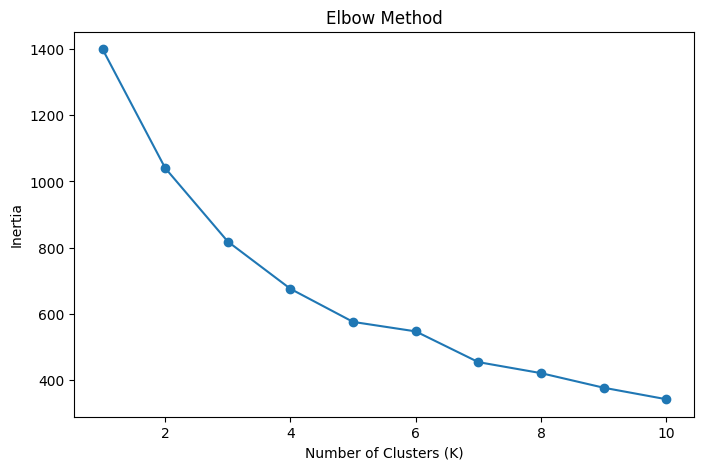

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.show()

In [ ]:

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    cluster_labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        cluster_labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.26343554378514666
K = 3, Silhouette Score = 0.31269808642585284
K = 4, Silhouette Score = 0.3178533649611367
K = 5, Silhouette Score = 0.30402670615661476
K = 6, Silhouette Score = 0.3106335202751695
K = 7, Silhouette Score = 0.3532615675504852
K = 8, Silhouette Score = 0.359981643286678
K = 9, Silhouette Score = 0.36781666059639906
K = 10, Silhouette Score = 0.3838502944252541


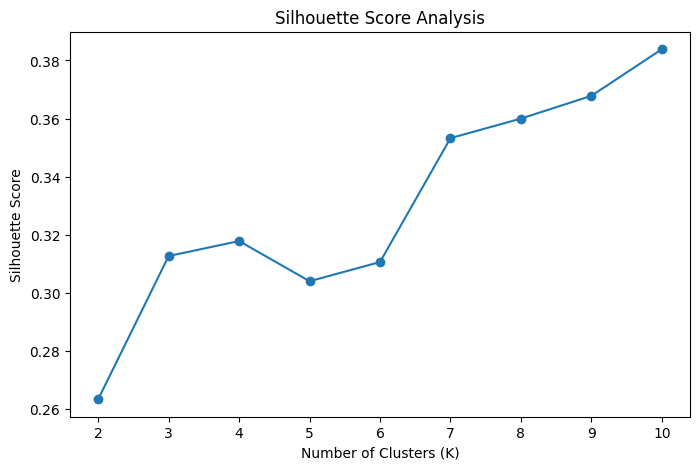

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.title('Silhouette Score Analysis')

plt.show()

In [ ]:
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    random_state=42
)

cluster_labels = kmeans.fit_predict(scaled_data)

print("K-Means model trained successfully!")

K-Means model trained successfully!


In [ ]:
df['Cluster'] = cluster_labels

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_Group,Income_Category,Spending_Category,Cluster
0,1,19,15,39,3,1,1,2
1,1,21,15,81,3,1,0,2
2,0,20,16,6,3,1,1,2
3,0,23,16,77,3,1,0,2
4,0,31,17,40,0,1,1,4


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,48
3,40
1,40
4,38
2,34


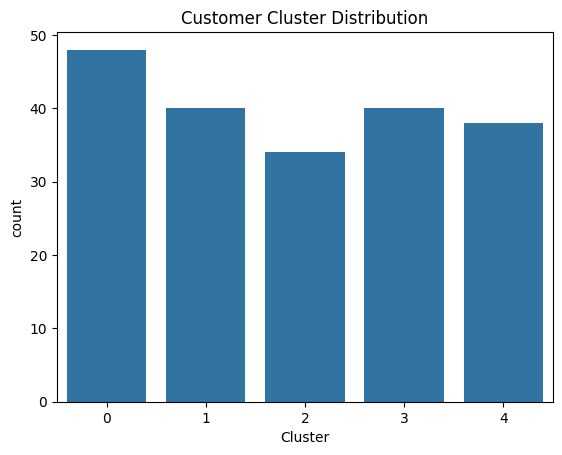

In [ ]:
sns.countplot(x=df['Cluster'])

plt.title('Customer Cluster Distribution')

plt.show()

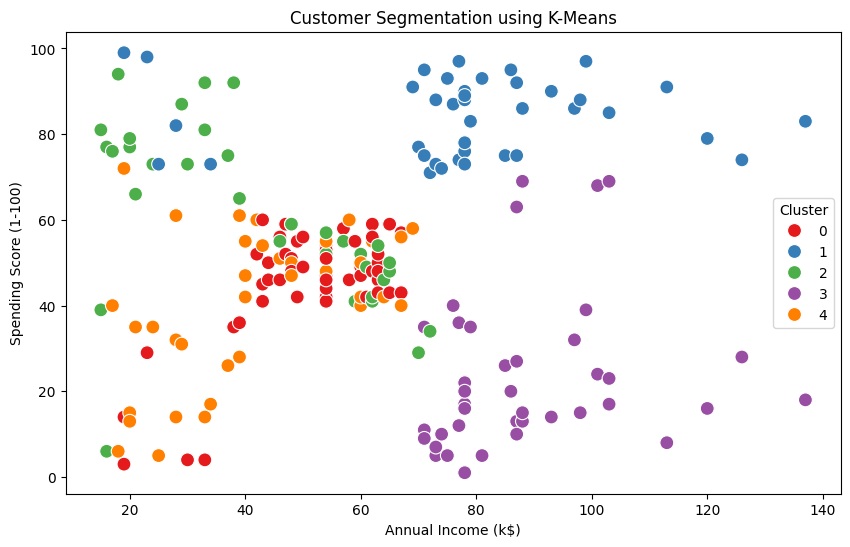

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation using K-Means')

plt.show()

In [ ]:
centroids = kmeans.cluster_centers_

centroids

array([[ 0.16284339,  1.29359458, -0.37285171, -0.20348968,  0.27510297,
         0.97482469,  0.87030695],
       [-0.03021836, -0.4270118 ,  0.67044602,  1.31119821, -0.92986289,
        -0.90650036, -1.40517244],
       [-0.05688162, -1.26625992, -0.70505671,  0.39872026,  1.73959994,
         0.4979129 , -0.03356821],
       [ 0.27196525,  0.0932967 ,  1.06931656, -1.06176969, -0.19576061,
        -1.1663253 , -0.05522512],
       [-0.40927324, -0.14976575, -0.72951824, -0.36226646, -0.71911582,
         0.50506322,  0.46796021]])

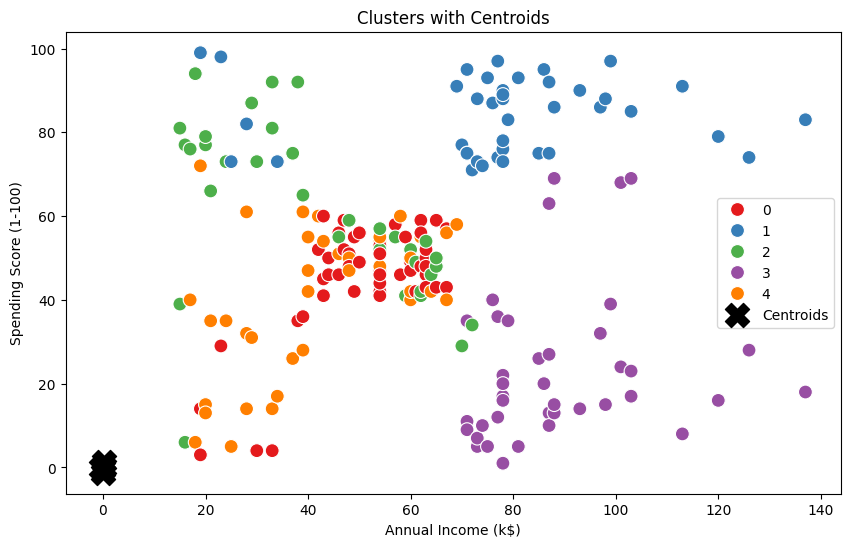

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Clusters with Centroids')

plt.legend()

plt.show()

In [ ]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = cluster_labels

pca_df.head()

,PCA1,PCA2,Cluster
0,0.890915,-1.778801,2
1,-0.160738,-2.809261,2
2,1.202598,-1.416637,2
3,-0.123465,-2.984970,2
4,0.157304,-0.671774,4
